#### test data 
>4.1 Data
- n = 100 
- y_i = 0.25 sin(pi x_i ) + epslon_i
- x_i = U(o,1)
- epslon_i = (1 - theta) N(0,sigma^2) + theta*n(o, 25sigam^2)
- sigma = 0.5
- theta = 0.1
- P(x) = 0.3 + 0.5 sin^2(5(x + 0.2))


In [4]:
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
np.random.seed(42) 
n = 100
sigma = 0.5
eta = 0.1

x = np.random.uniform(0,1,n)

clean_noise = np.random.normal(0,sigma,n)
contaminated_noise = np.random.normal(0,0.25*sigma,n)
epsilon = (1-eta)*clean_noise + eta*contaminated_noise

y_true = 0.25 * np.pi * np.sin(np.pi * x)
y = y_true + epsilon

In [7]:
y

NameError: name 'haed' is not defined

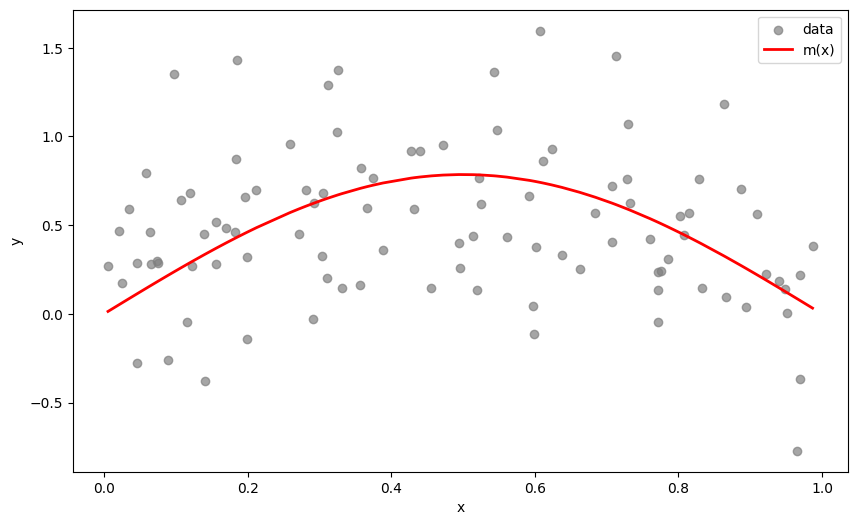

In [4]:
plt.figure(figsize=(10,6))
plt.scatter(x, y, label = 'data', alpha = 0.7,color = 'gray')
plt.plot(np.sort(x),0.25 * np.pi * np.sin(np.pi * np.sort(x)), 'r-',label= 'm(x)' , linewidth = 2)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [5]:
p_x = 0.3 + 0.5 * np.sin(5 * (x + 0.2))**2
p_x

array([0.33528854, 0.42761355, 0.79862737, 0.58305374, 0.77841536,
       0.77843987, 0.76171325, 0.63191194, 0.58913056, 0.78534889,
       0.69830416, 0.38827271, 0.70547133, 0.68888201, 0.7449176 ,
       0.74242066, 0.46898133, 0.40751819, 0.30016437, 0.50035658,
       0.61536809, 0.7920198 , 0.4981155 , 0.34646749, 0.30956516,
       0.77755497, 0.71402724, 0.38673137, 0.56752662, 0.74485003,
       0.60491523, 0.76132785, 0.7704564 , 0.43162041, 0.39657349,
       0.7476213 , 0.4681032 , 0.79660986, 0.75877969, 0.30174849,
       0.79922442, 0.35382492, 0.72458736, 0.52563132, 0.58106677,
       0.72425644, 0.45155924, 0.39804717, 0.45567506, 0.7400863 ,
       0.38889358, 0.78678864, 0.45278011, 0.56182079, 0.58117319,
       0.49466994, 0.79181032, 0.72087748, 0.74291971, 0.42127   ,
       0.31938697, 0.54972467, 0.71261676, 0.3613336 , 0.52579893,
       0.44645976, 0.79109879, 0.75672949, 0.78064451, 0.35838762,
       0.78900563, 0.7158273 , 0.66642486, 0.73632089, 0.78430

In [6]:
delta = np.random.rand(n) < p_x
print(f"percentage of existing values: {np.mean(delta):.1%}")

percentage of existing values: 49.0%


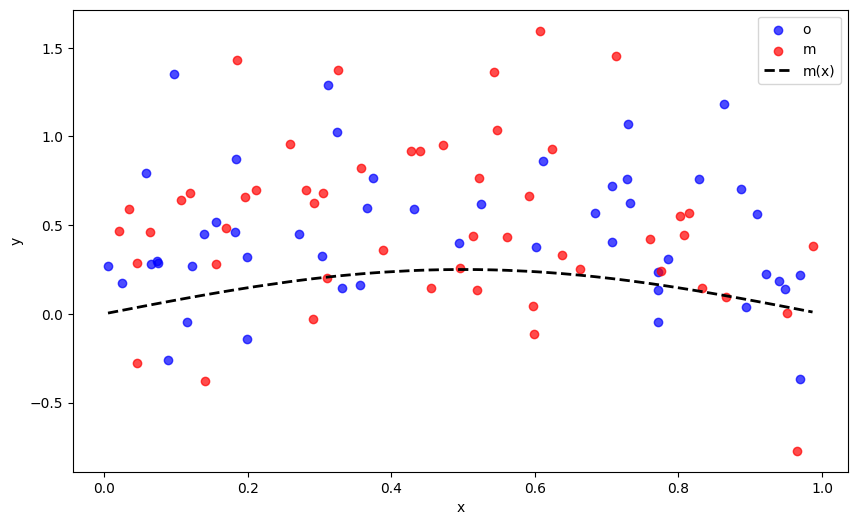

In [7]:
plt.figure(figsize = (10,6))
plt.scatter(x[delta==1],y[delta==1],label='o',color='blue',alpha=0.7)
plt.scatter(x[delta==0],y[delta==0],label='m',color='red',alpha=0.7)
plt.plot(np.sort(x),0.25 * np.sin(np.pi * np.sort(x)), 'k--' ,label ='m(x)',linewidth = 2)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()


In [8]:
def gussian_kernel(u):
    return np.exp(-0.5 * u**2)

In [9]:
x0 = 0.5
h = 0.3
numerator = gussian_kernel((x - x0) / h) * delta
denominator = np.sum(numerator)
if denominator == 0:
    weights = np.zeros_like(x)
else :
    weights = numerator / denominator

In [10]:
np.sum(weights)

np.float64(0.9999999999999998)

In [11]:
def huber_psi(u,k=1.345):
    return np.where(np.abs(u) <= k, u, k * np.sign(u))

In [12]:
from scipy.stats import median_abs_deviation
def mad_scale(y, delta):
    y_obs = y[delta == 1]
    return median_abs_deviation(y_obs, nan_policy ='omit')

In [13]:
sigma_hat = mad_scale(y,delta)

In [14]:
m_hat = np.average(y[delta == 1], weights = weights[delta == 1])

In [15]:
max_iter = 50
tol = 1e-6
converged = False

for iteration in range(max_iter):
    residuals = y - m_hat
    scaled_residuals = residuals / (sigma_hat + 1e-8)
    psi_vals = huber_psi(scaled_residuals, k=1.345)

    with np.errstate(divide='ignore' , invalid='ignore'):
        u_weights = np.where(np.abs(scaled_residuals) > 1e-8,
                             psi_vals / scaled_residuals,
                             psi_vals * 0 + 1)
    final_weights = weights * u_weights * delta
    if np.sum(final_weights) == 0:
        break
    m_hat_new = np.average(y, weights = final_weights)
    if abs(m_hat_new - m_hat) < tol:
        converged = True
        break
    m_hat = m_hat_new

In [1]:
import sys
sys.path.append("../src")
from data_simulation import data_sim
from missing_mechanism import missing_mechanism
from slms import slms_estimator
from kernels import gaussian_kernel
from psi_functions import huber_psi

In [2]:
import numpy as np 
x0 = 0.5
h = 0.3
x,y=data_sim()
delta = missing_mechanism(x=x)
m_hat = slms_estimator(
    x=x,
    y=y,
    delta=delta,
    x0=x0,
    h=h,
    psi=huber_psi,
    kernel=gaussian_kernel
)
print(f"SLMS estimate at x0={x0}: {m_hat:.3f}")
print(f"True value: {0.25 * np.sin(np.pi * x0):.3f}")


SLMS estimate at x0=0.5: 0.474
True value: 0.250


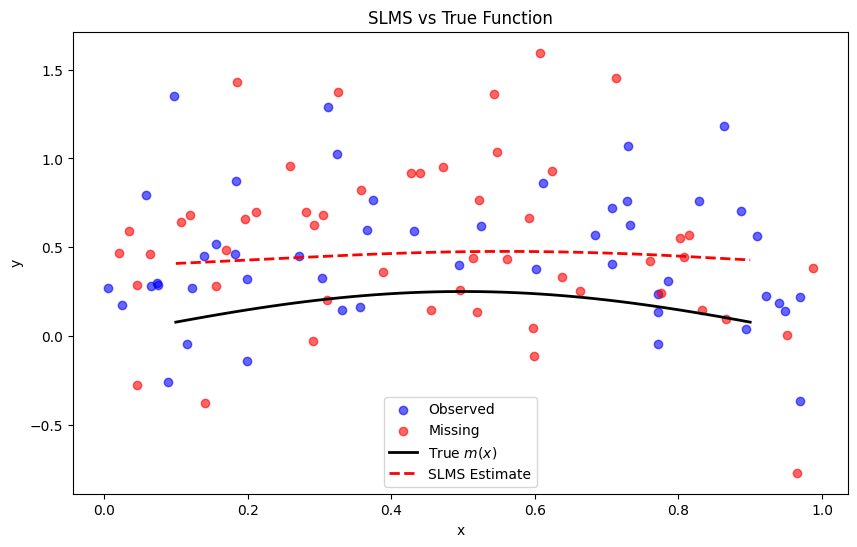

In [3]:
import matplotlib.pyplot as plt
x_grid = np.linspace(0.1, 0.9, 50)
m_estimates = []

for x0 in x_grid:
    m_hat = slms_estimator(x, y, delta, x0, h=0.3, psi=huber_psi, kernel=gaussian_kernel)
    m_estimates.append(m_hat)

# الرسم
plt.figure(figsize=(10, 6))
plt.scatter(x[delta==1], y[delta==1], label='Observed', alpha=0.6, color='blue')
plt.scatter(x[delta==0], y[delta==0], label='Missing', alpha=0.6, color='red')
plt.plot(x_grid, 0.25 * np.sin(np.pi * x_grid), 'k-', label='True $m(x)$', lw=2)
plt.plot(x_grid, m_estimates, 'r--', label='SLMS Estimate', lw=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('SLMS vs True Function')
plt.legend()
plt.show()

In [4]:
from ilms import ilms_estimator 
from kernels import gaussian_kernel,epanechnikov_kernel

x0 = 0.5
h_slms = 0.3
gamma = 0.25

m_hat_ilms = ilms_estimator(
    x=x,
    y=y,
    delta=delta,
    x0=x0,
    h=h_slms,
    gamma=gamma,
    psi=huber_psi,
    kernel=gaussian_kernel,
    imputation_kernel=gaussian_kernel
)

print(f"ILMS estimate at x0={x0}: {m_hat_ilms:.3f}")
print(f"True value: {0.25 * np.sin(np.pi * x0):.3f}")

ILMS estimate at x0=0.5: 0.459
True value: 0.250


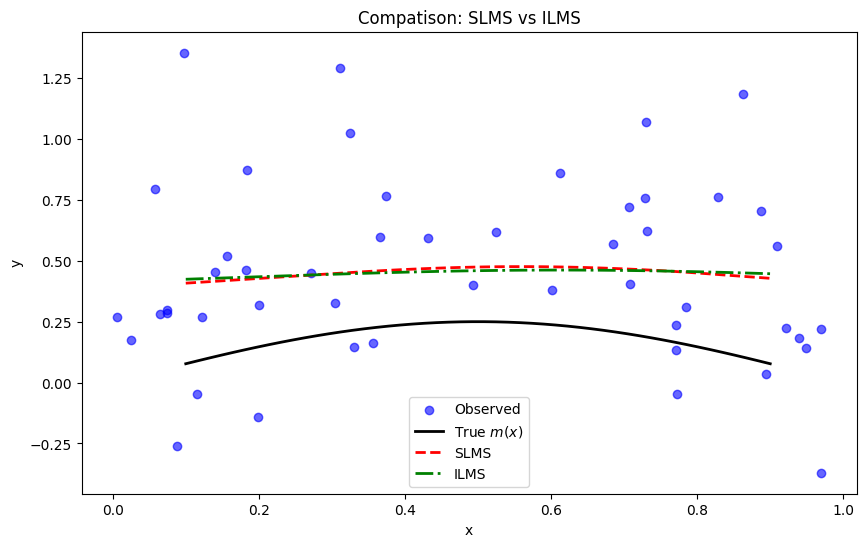

In [5]:
x_grid = np.linspace(0.1,0.9,50)
m_slms = [slms_estimator(x,y,delta,x0,h=0.3,psi=huber_psi,kernel=gaussian_kernel) for x0 in x_grid]
m_ilms = [ilms_estimator(x,y,delta,x0,h=0.3,gamma=0.25,psi=huber_psi,kernel=gaussian_kernel,imputation_kernel=gaussian_kernel) for x0 in x_grid]

plt.figure(figsize=(10,6))
plt.scatter(x[delta==1],y[delta==1],label='Observed',alpha=0.6,color='blue')
plt.plot(x_grid,0.25*np.sin(np.pi * x_grid),'k-',label = 'True $m(x)$',lw =2)
plt.plot(x_grid,m_slms,'r--',label='SLMS',lw=2)
plt.plot(x_grid,m_ilms,'g-.',label='ILMS',lw=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Compatison: SLMS vs ILMS')
plt.legend()
plt.show()
         

In [6]:
from evaluation import compute_mise,plot_comparison
from slms import slms_estimator
from ilms import ilms_estimator
from kernels import gaussian_kernel
from psi_functions import huber_psi
from nadaraya_watson import nadaraya_watson
h= 0.3
gamma = 0.25
x_grid = np.linspace(0.1,0.9,50)

nw_estimates = [
    nadaraya_watson(x, y, delta, x0, h, kernel=gaussian_kernel)
    for x0 in x_grid
]


slms_estimates = [
    slms_estimator(x,y,delta,x0,h,psi=huber_psi, kernel=gaussian_kernel)
    for x0 in x_grid
]
ilms_estimates = [
    ilms_estimator(x,y,delta,x0,h,gamma,psi=huber_psi,kernel=gaussian_kernel,imputation_kernel=gaussian_kernel)
    for x0 in x_grid
]

plot_comparison(x,y,delta,slms_estimates, ilms_estimates,nw_estimates,x_grid, lambda x: 0.25 * np.sin(np.pi * x))

true_values = 0.25 * np.sin(np.pi * x_grid)
mise_slms = np.mean((true_values - slms_estimates)**2)
mise_ilms = np.mean((true_values - ilms_estimates)**2)
ise_nw = np.mean((true_values - nw_estimates)**2)

print(f"ISE Nadaraya-Watson: {ise_nw:.4f}")
print(f"MISE SLMS: {mise_slms:.4f}")
print(f"MISE ILMS: {mise_slms:.4f}")


ModuleNotFoundError: No module named 'nadaraya_watson'

In [8]:
R = 50
v_grid = np.linspace(0.1, 0.9, R)

true_values = 0.25 * np.sin(np.pi * v_grid)

slms_estimates = [slms_estimator(x, y, delta, x0, h=0.3, psi=huber_psi, kernel=gaussian_kernel) for x0 in v_grid]
ilms_estimates = [ilms_estimator(x, y, delta, x0, h=0.3, gamma=0.25, psi=huber_psi, kernel=gaussian_kernel, imputation_kernel=gaussian_kernel) for x0 in v_grid]

ise_slms = np.mean((true_values - slms_estimates)**2)
ise_ilms = np.mean((true_values - ilms_estimates)**2)

print(f"ISE SLMS: {ise_slms:.4f}")
print(f"ISE ILMS: {ise_ilms:.4f}")

ISE SLMS: 0.0719
ISE ILMS: 0.0716
